<a href="https://colab.research.google.com/github/MuhammadShofiyyurrohman/machine-learning/blob/main/pertemuanMandiri05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# menghubungkan colab dengan google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
# Import library
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
# Baca dataset Iris
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/praktikum_ml/praktikum05/data/Iris.csv")
print(df.head())


   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [6]:
# Siapkan variabel fitur (X) dan target (y)
X = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
y = df['Species']


In [7]:
# Bagi data: 80% untuk training, 20% untuk testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [8]:
# Buat model Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [9]:
# Uji model (prediksi data test)
y_pred = dt.predict(X_test)


In [10]:
# Evaluasi model
print("Akurasi:", round(accuracy_score(y_test, y_pred)*100, 2), "%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Akurasi: 93.33 %

Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



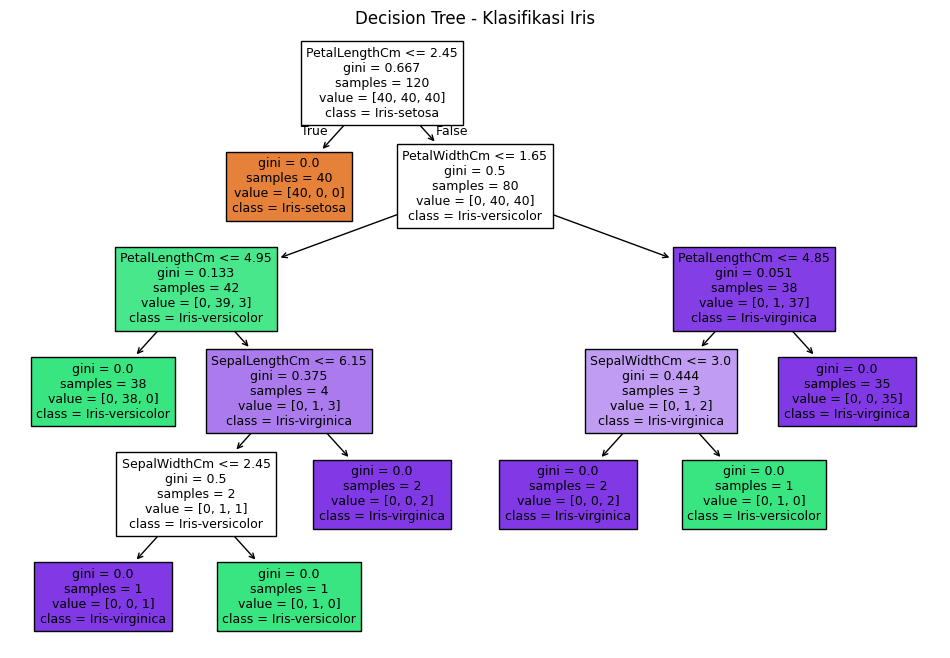

In [11]:
# Visualisasi Decision Tree
plt.figure(figsize=(12, 8))
plot_tree(
    dt,
    feature_names=X.columns,
    class_names=dt.classes_,
    filled=True,
    fontsize=9
)
plt.title("Decision Tree - Klasifikasi Iris")
plt.show()


In [12]:
# Tampilkan hasil prediksi dari data testing
hasil = pd.DataFrame({
    'SepalLengthCm': X_test['SepalLengthCm'],
    'SepalWidthCm': X_test['SepalWidthCm'],
    'PetalLengthCm': X_test['PetalLengthCm'],
    'PetalWidthCm': X_test['PetalWidthCm'],
    'Species_Asli': y_test,
    'Species_Prediksi': y_pred
})
print(hasil.head())


     SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
38             4.4           3.0            1.3           0.2   
127            6.1           3.0            4.9           1.8   
57             4.9           2.4            3.3           1.0   
93             5.0           2.3            3.3           1.0   
42             4.4           3.2            1.3           0.2   

        Species_Asli Species_Prediksi  
38       Iris-setosa      Iris-setosa  
127   Iris-virginica   Iris-virginica  
57   Iris-versicolor  Iris-versicolor  
93   Iris-versicolor  Iris-versicolor  
42       Iris-setosa      Iris-setosa  
